<a href="https://colab.research.google.com/github/austinmallie/ADS599_Capstone/blob/main/EDA/Hospital_Cost_Report_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

token    = userdata.get('GitHub')
owner    = "austinmallie"
repo     = "ADS599_Capstone"
repo_url = f"https://{token}@github.com/{owner}/{repo}.git"

# Only clone if the folder doesn't exist already
if not os.path.exists(repo):
    !git clone {repo_url}
else:
    print("Repo already cloned. Pulling latest changes...")
    %cd {repo}
    !git pull

%cd /content/{repo}


Cloning into 'ADS599_Capstone'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 134 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 20.41 MiB | 5.04 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/ADS599_Capstone


Import Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings, re, os
warnings.filterwarnings('ignore')

# Define a helper function to save figures
def save_fig(fig_name, fig_path="EDA", dpi=None):
    path = os.path.join("ADS599_Capstone", fig_path, fig_name)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.savefig(path, bbox_inches='tight', dpi=dpi)
    print(f" Saved → {path}")

Import Hospital Cost Reports from 2014-2023

In [3]:
FILE_MAP = {
    2014: 'Hospital_Provider_Cost_Report_2014.csv',
    2015: 'Hospital_Provider_Cost_Report_2015.csv',
    2016: 'Hospital_Provider_Cost_Report_2016.csv',
    2017: 'Hospital_Provider_Cost_Report_2017.csv',
    2018: 'Hospital_Provider_Cost_Report_2018.csv',
    2019: 'Hospital_Provider_Cost_Report_2019.csv',
    2021: 'Hospital_Provider_Cost_Report_2021.csv',
    2022: 'Hospital_Provider_Cost_Report_2022.csv',
    2023: 'CostReport_2023_Final.csv',
}

frames = []
for year, fname in FILE_MAP.items():
    path = os.path.join("Data-Folder/Cost-Report-Data", fname)
    tmp  = pd.read_csv(path, low_memory=False)
    tmp['report_year'] = year
    frames.append(tmp)
    print(f"  {year}: {len(tmp):,} rows  |  {tmp.shape[1]} cols")

print(f"\n Total files loaded: {len(frames)}")



  2014: 6,250 rows  |  118 cols
  2015: 6,257 rows  |  118 cols
  2016: 6,211 rows  |  118 cols
  2017: 6,174 rows  |  118 cols
  2018: 6,160 rows  |  118 cols
  2019: 6,121 rows  |  118 cols
  2021: 6,053 rows  |  118 cols
  2022: 6,064 rows  |  118 cols
  2023: 6,103 rows  |  118 cols

 Total files loaded: 9


Column Consistency across years

In [4]:

all_cols   = [set(f.columns) for f in frames]
base_cols  = set.intersection(*all_cols)
extra_cols = set.union(*all_cols) - base_cols

print(f"Columns present in ALL years  : {len(base_cols)}")
print(f"Columns present in SOME years : {len(extra_cols)}")
if extra_cols:
    print("  Extra columns:", extra_cols)

Columns present in ALL years  : 118
Columns present in SOME years : 0


Standardise Column Names

In [5]:
# Standardize Column Names: strip whitespace, lowercase, replace special chars
def clean_col(c):
    c = c.strip()
    c = re.sub(r'[^A-Za-z0-9]+', '_', c)
    return c.lower().strip('_')

for i, f in enumerate(frames):
    frames[i].columns = [clean_col(c) for c in f.columns]

#  Stack all years
df = pd.concat(frames, ignore_index=True, sort=False)

print(f"Combined shape : {df.shape}")
print(f"Years present  : {sorted(df['report_year'].unique())}")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Combined shape : (55393, 118)
Years present  : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]
Memory usage   : 80.1 MB


Standardize Date and Rename Columns for Easier Formatting and Reading

In [7]:
# Standardise date columns
for col in ['fiscal_year_begin_date', 'fiscal_year_end_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Rename key columns for readability
rename = {
    'provider_ccn'                              : 'ccn',
    'state_code'                                : 'state',
    'rural_versus_urban'                        : 'rural_urban',
    'type_of_control'                           : 'control_type',
    'number_of_beds'                            : 'beds',
    'total_costs'                               : 'total_costs',
    'net_patient_revenue'                       : 'net_patient_revenue',
    'net_income'                                : 'net_income',
    'total_patient_revenue'                     : 'total_patient_revenue',
    'less_total_operating_expense'              : 'total_operating_expense',
    'total_salaries_from_worksheet_a'           : 'total_salaries',
    'total_discharges_v_xviii_xix_unknown'      : 'total_discharges',
    'total_days_v_xviii_xix_unknown'            : 'total_days',
    'inpatient_revenue'                         : 'inpatient_revenue',
    'outpatient_revenue'                        : 'outpatient_revenue',
    'cost_of_charity_care'                      : 'charity_care_cost',
    'total_bad_debt_expense'                    : 'bad_debt_expense',
    'total_assets'                              : 'total_assets',
    'total_liabilities'                         : 'total_liabilities',
    'total_fund_balances'                       : 'total_fund_balances',
    'fte_employees_on_payroll'                  : 'fte_employees',
    'contract_labor_direct_patient_care'        : 'contract_labor',
    'disproportionate_share_adjustment'         : 'dsh_adjustment',
    'allowable_dsh_percentage'                  : 'dsh_pct',
    'net_revenue_from_medicaid'                 : 'medicaid_net_revenue',
    'cost_to_charge_ratio'                      : 'cost_to_charge_ratio',
    'depreciation_cost'                         : 'depreciation_cost',
    'overhead_non_salary_costs'                 : 'overhead_costs',
    'medicare_cbsa_number'                      : 'cbsa',
}
df.rename(columns={k: v for k, v in rename.items() if k in df.columns}, inplace=True)

print(f" Schema reconciled. Final columns: {df.shape[1]}")
df.head(2)

 Schema reconciled. Final columns: 118


,rpt_rec_num,ccn,hospital_name,street_address,city,state,zip_code,county,cbsa,rural_urban,...,total_other_income,total_income,total_other_expenses,net_income,cost_to_charge_ratio,medicaid_net_revenue,medicaid_charges,net_revenue_from_stand_alone_chip,stand_alone_chip_charges,report_year
0,549185,104075,NORTH TAMPA BEHAVIORAL SYSTEM,29910 SR 56,WESLEY CHAPEL,FL,33543,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
1,550904,514011,HIGHLAND CLARKSBUGS,3 HOSPITAL PLAZA,CLARKSBURG,WV,26301,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014


##Data Quality Assessment

In [8]:
# Overall missing-value summary
total   = len(df)
miss    = df.isnull().sum()
miss_pct = (miss / total * 100).round(2)
miss_df = (pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
             .query('missing_count > 0')
             .sort_values('missing_pct', ascending=False))

print(f"Total rows  : {total:,}")
print(f"Total cols  : {df.shape[1]}")
print(f"Cols with nulls: {len(miss_df)}\n")
print(miss_df.head(30).to_string())

Total rows  : 55,393
Total cols  : 118
Cols with nulls: 108

                                                   missing_count  missing_pct
drg_amounts_other_than_outlier_payments                    55393       100.00
hospital_total_days_title_v_for_adults_peds                54008        97.50
hospital_total_discharges_title_v_for_adults_peds          53945        97.39
total_discharges_title_v                                   53945        97.39
total_days_title_v                                         53873        97.26
notes_receivable                                           52814        95.34
unsecured_loans                                            52750        95.23
wage_related_costs_rhc_fqhc                                51853        93.61
wage_related_costs_for_part_a_teaching_physicians          51699        93.33
health_information_technology_designated_assets            50438        91.05
wage_related_costs_for_interns_and_residents               48274        87.15
mor

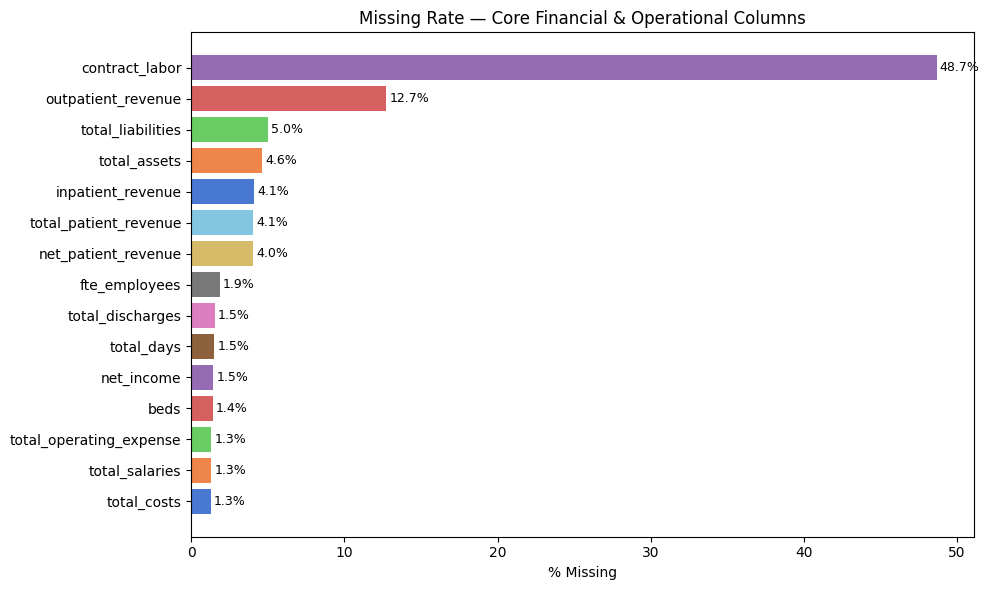

In [24]:
# Missingness bar chart for core financial columns
fin_cols = [c for c in ['total_costs','net_patient_revenue','net_income',
                         'total_patient_revenue','total_operating_expense',
                         'total_salaries','beds','total_discharges','total_days',
                         'inpatient_revenue','outpatient_revenue','total_assets',
                         'total_liabilities','fte_employees','contract_labor']
            if c in df.columns]

miss_fin = df[fin_cols].isnull().mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(miss_fin.index, miss_fin.values,
               color=sns.color_palette('muted', len(miss_fin)))
ax.set_xlabel('% Missing')
ax.set_title('Missing Rate — Core Financial & Operational Columns')
for bar, val in zip(bars, miss_fin.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


In [25]:
# Duplicates & year distribution
dupes = df.duplicated(subset=['rpt_rec_num']).sum()
print(f"Duplicate rpt_rec_num rows: {dupes:,}")
print("\nRows per reporting year:")
print(df['report_year'].value_counts().sort_index().to_string())

Duplicate rpt_rec_num rows: 0

Rows per reporting year:
report_year
2014    6250
2015    6257
2016    6211
2017    6174
2018    6160
2019    6121
2021    6053
2022    6064
2023    6103


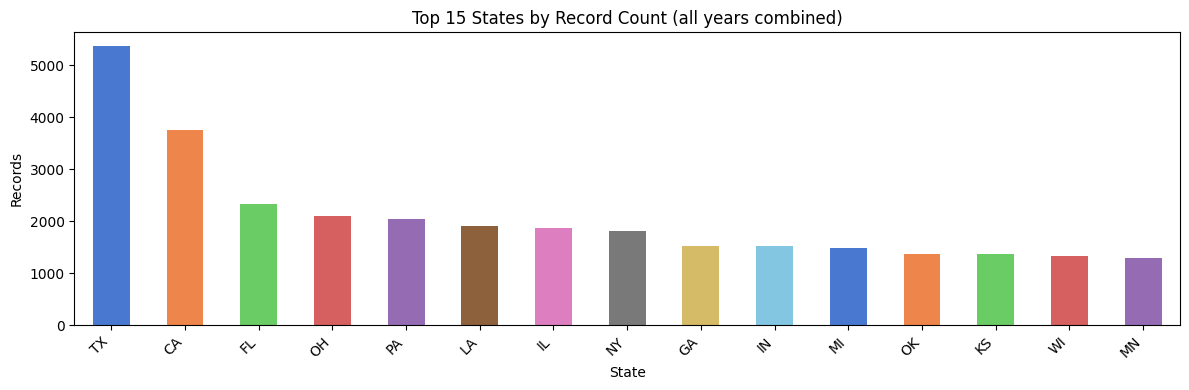

In [26]:
# Top 15 states by record count
if 'state' in df.columns:
    top_states = df['state'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 4))
    top_states.plot(kind='bar', ax=ax,
                    color=sns.color_palette('muted', 15))
    ax.set_title('Top 15 States by Record Count (all years combined)')
    ax.set_xlabel('State'); ax.set_ylabel('Records')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


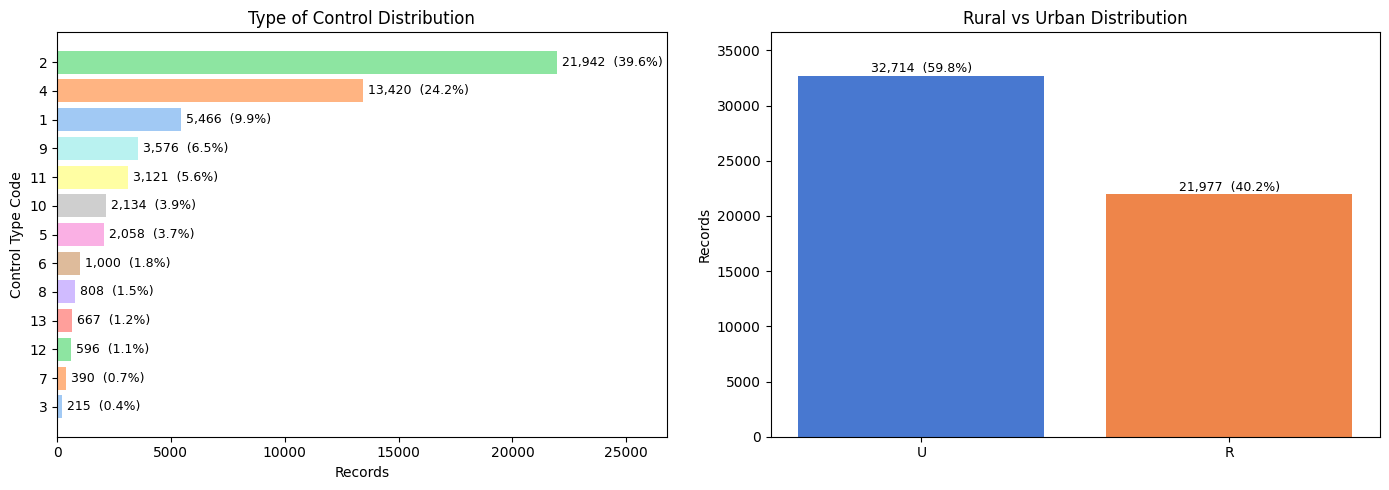

In [27]:
# Control type & Rural/Urban breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'control_type' in df.columns:
    ct = df['control_type'].value_counts().sort_values(ascending=True)
    bars = axes[0].barh(ct.index.astype(str), ct.values,
                        color=sns.color_palette('pastel', len(ct)))
    axes[0].set_title('Type of Control Distribution')
    axes[0].set_xlabel('Records')
    axes[0].set_ylabel('Control Type Code')
    # Add value labels on each bar
    for bar, val in zip(bars, ct.values):
        axes[0].text(val + (ct.values.max() * 0.01),
                     bar.get_y() + bar.get_height() / 2,
                     f'{val:,}  ({val/ct.sum()*100:.1f}%)',
                     va='center', fontsize=9)
    axes[0].set_xlim(0, ct.values.max() * 1.22)

if 'rural_urban' in df.columns:
    ru = df['rural_urban'].value_counts()
    axes[1].bar(ru.index, ru.values,
                color=sns.color_palette('muted', len(ru)))
    axes[1].set_title('Rural vs Urban Distribution')
    axes[1].set_ylabel('Records')
    # Add value labels on top of each bar
    for i, (label, val) in enumerate(ru.items()):
        axes[1].text(i, val + (ru.values.max() * 0.01),
                     f'{val:,}  ({val/ru.sum()*100:.1f}%)',
                     ha='center', fontsize=9)
    axes[1].set_ylim(0, ru.values.max() * 1.12)

plt.tight_layout()
plt.show()

 The Type of Control Distribution shows that the largest share of hospitals in the dataset falls under Code 2: Voluntary Non-Profit (Other), accounting for 21,942 hospitals or 39.6% of all records. This indicates that non-profit organizations that are not church affiliated make up the largest portion of hospitals. The second largest category is Code 4: Proprietary (Corporation) with 13,420 hospitals (24.2%), suggesting that corporate-owned, for-profit healthcare systems also play a major role in hospital ownership. Code 1: Voluntary Non-Profit (Church) represents 5,466 hospitals (9.9%), indicating that religious organizations maintain a smaller but still notable presence in the healthcare system. Government-controlled hospitals appear in several categories such as County (Code 9), Hospital District (Code 11), State (Code 10), City (Code 12), and Other Governmental entities (Code 13), though each of these categories individually represents a relatively small portion of the dataset. This overall pattern suggests that hospital ownership is largely concentrated among non-profit institutions and corporate healthcare systems, while government-operated facilities make up a smaller but important share of the healthcare infrastructure.

The Rural vs Urban Distribution further shows that hospitals are more commonly located in urban areas. The dataset contains 32,714 urban hospitals (59.8%) compared to 21,977 rural hospitals (40.2%).

##Univariate Analysis

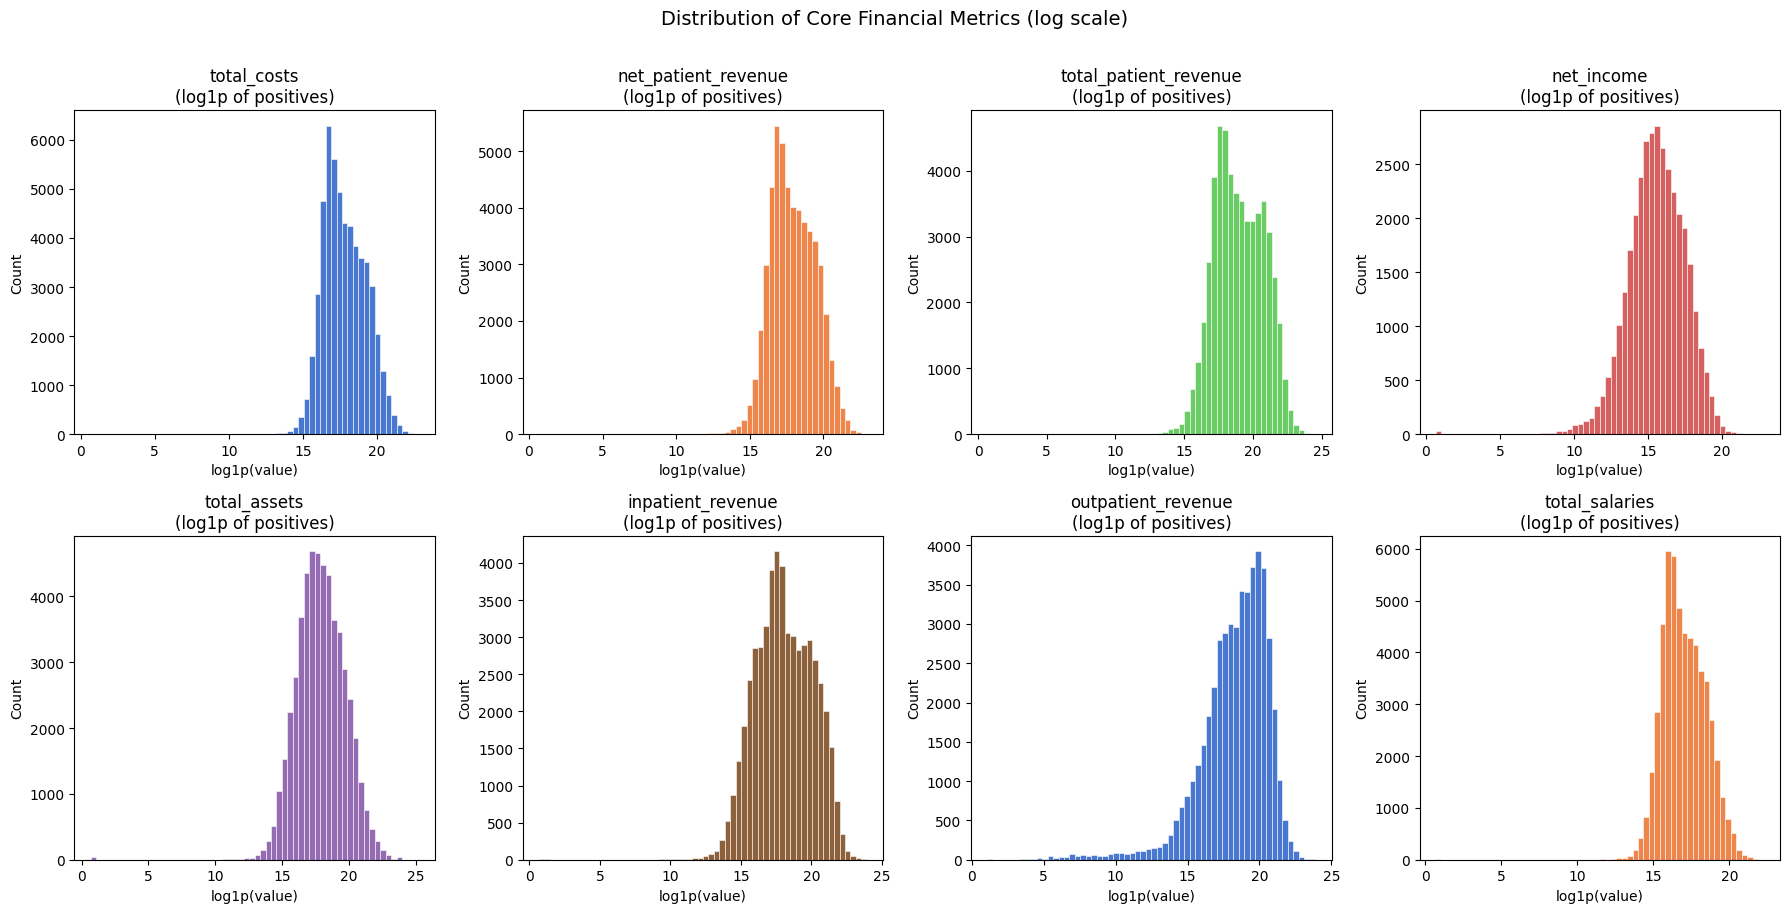

In [28]:
# Distribution of core financial metrics (log scale)
plot_cols = [c for c in ['total_costs','net_patient_revenue','total_patient_revenue',
                          'net_income','total_assets','inpatient_revenue',
                          'outpatient_revenue','total_salaries'] if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    vals     = df[col].dropna()
    log_vals = np.log1p(vals[vals > 0])
    axes[i].hist(log_vals, bins=60,
                 color=sns.color_palette('muted')[i % 6],
                 edgecolor='white', linewidth=0.4)
    axes[i].set_title(f'{col}\n(log1p of positives)')
    axes[i].set_xlabel('log1p(value)')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Core Financial Metrics (log scale)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Across most variables, the histograms display approximately bell-shaped distributions once the logarithmic transformation is applied, indicating that although the original financial data is highly skewed (with a few very large hospital systems), the transformation reveals a more comparable range of financial activity among most hospitals

Overall, this visualization highlights the financial structure of hospitals reported in the CMS cost report dataset, showing that while hospitals differ significantly in scale, reflected by wide revenue, cost, and asset ranges—their financial relationships remain consistent. Larger hospitals generally have higher revenues, costs, assets, and salary expenditures, while net income remains more constrained, reflecting the relatively thin margins common in hospital operations.

 Saved → ADS599_Capstone/EDA/05_operational_distributions.png


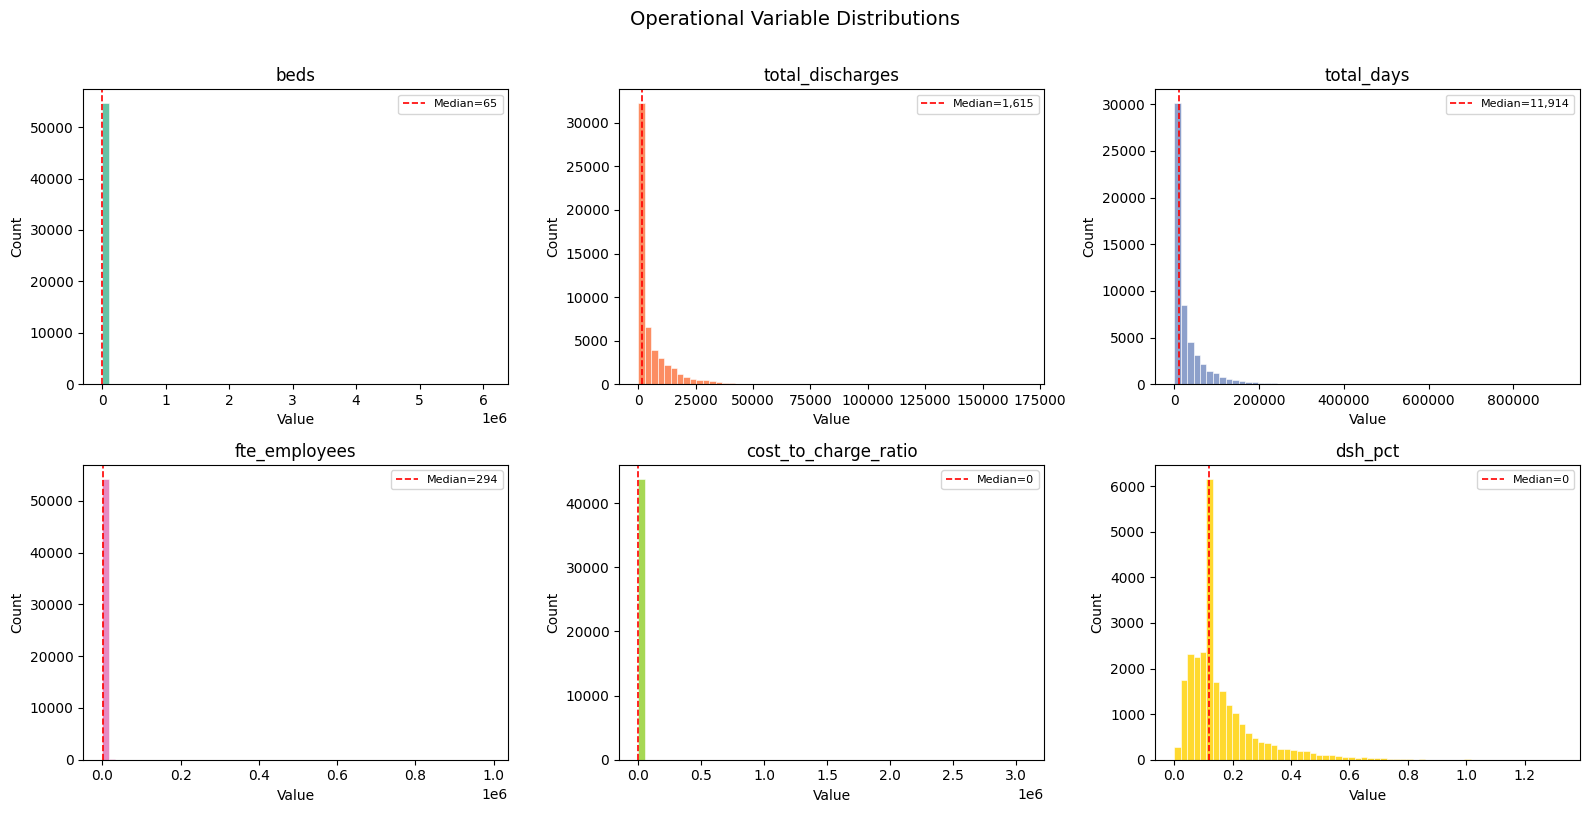

In [20]:
# Operational variable distributions
op_cols = [c for c in ['beds','total_discharges','total_days',
                        'fte_employees','cost_to_charge_ratio','dsh_pct']
           if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(op_cols[:6]):
    vals = df[col].dropna()
    vals = vals[vals >= 0]
    axes[i].hist(vals, bins=60, color=sns.color_palette('Set2')[i],
                 edgecolor='white', linewidth=0.4)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count')
    med = vals.median()
    axes[i].axvline(med, color='red', linestyle='--', linewidth=1.2,
                    label=f'Median={med:,.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Operational Variable Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [29]:
# Descriptive statistics table
key_cols = [c for c in ['beds','total_costs','net_patient_revenue','net_income',
                         'total_patient_revenue','total_operating_expense',
                         'total_salaries','total_discharges','fte_employees',
                         'total_assets','total_liabilities','charity_care_cost',
                         'bad_debt_expense','dsh_pct','cost_to_charge_ratio']
            if c in df.columns]

desc = df[key_cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
desc['skewness'] = df[key_cols].skew()
desc['kurtosis'] = df[key_cols].kurtosis()
pd.set_option('display.float_format', '{:,.2f}'.format)
print(desc.to_string())



                            count           mean              std               min              1%             5%           25%            50%            75%              95%              99%               max  skewness  kurtosis
beds                    54,615.00         246.40        26,069.47              1.00            8.00          15.00         25.00          65.00         170.00           458.00           804.00      6,092,016.00    233.64 54,596.54
total_costs             54,690.00 148,770,365.61   291,803,351.83              1.00    3,234,626.90   6,960,979.90 18,239,809.75  45,552,992.50 155,542,589.00   605,588,311.50 1,375,194,278.37  7,921,779,632.00      6.18     69.77
net_patient_revenue     53,151.00 183,245,423.06   377,454,632.76 -3,147,620,615.00    2,147,775.00   6,268,945.00 19,433,606.00  52,894,544.00 188,273,149.00   750,058,642.00 1,769,621,624.50  9,309,983,652.00      6.46     73.35
net_income              54,588.00   9,143,778.21    88,870,014.74 -3,955,819

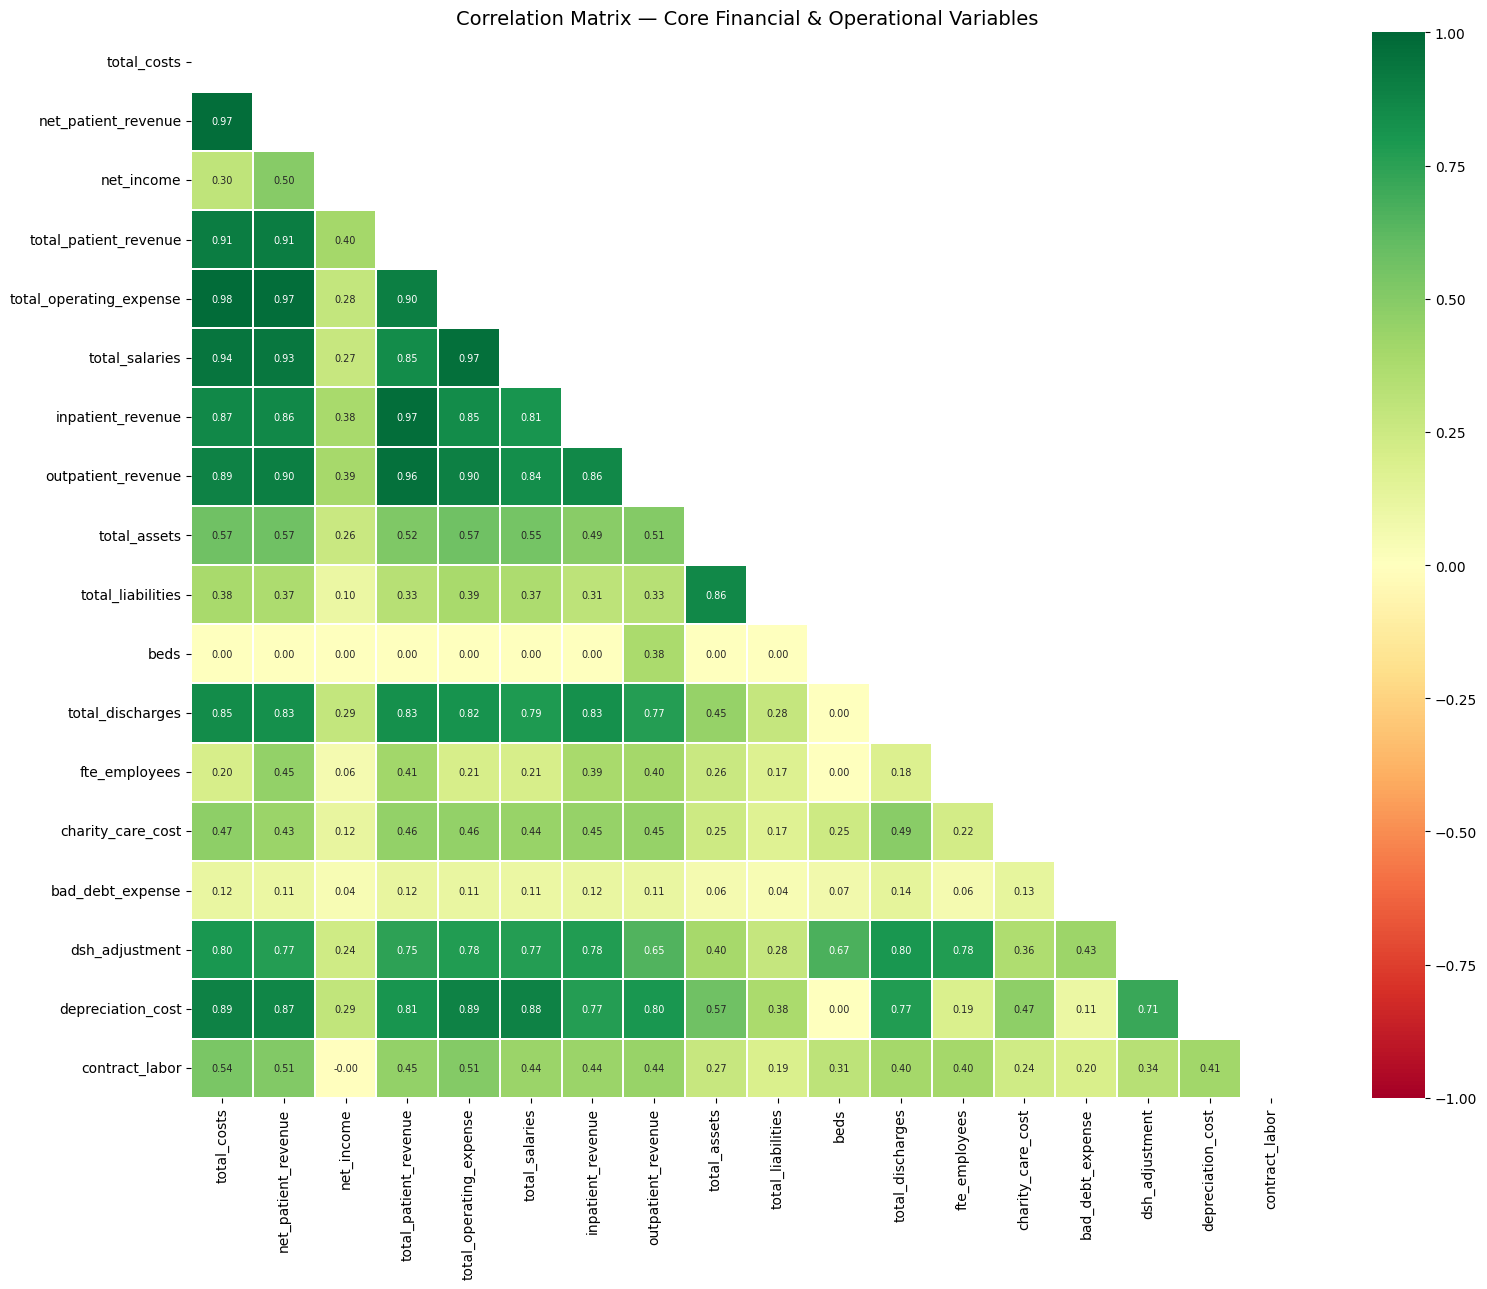

In [31]:
# Pearson correlation heatmap
corr_cols = [c for c in ['total_costs','net_patient_revenue','net_income',
                          'total_patient_revenue','total_operating_expense',
                          'total_salaries','inpatient_revenue','outpatient_revenue',
                          'total_assets','total_liabilities','beds',
                          'total_discharges','fte_employees','charity_care_cost',
                          'bad_debt_expense','dsh_adjustment','depreciation_cost',
                          'contract_labor'] if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, ax=ax,
            annot_kws={'size': 7}, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Core Financial & Operational Variables',
             fontsize=14)
plt.tight_layout()
plt.show()


In [33]:
# Top correlated pairs
corr_pairs = (corr_matrix
              .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
              .stack().reset_index())
corr_pairs.columns = ['var1','var2','correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
top_pairs = corr_pairs.sort_values('abs_corr', ascending=False).head(20)

print("Top 20 strongest correlations:")
print(top_pairs.to_string(index=False))



Top 20 strongest correlations:
                   var1                    var2  correlation  abs_corr
total_operating_expense             total_costs         0.98      0.98
total_operating_expense     net_patient_revenue         0.97      0.97
    net_patient_revenue             total_costs         0.97      0.97
      inpatient_revenue   total_patient_revenue         0.97      0.97
         total_salaries total_operating_expense         0.97      0.97
     outpatient_revenue   total_patient_revenue         0.96      0.96
         total_salaries             total_costs         0.94      0.94
         total_salaries     net_patient_revenue         0.93      0.93
  total_patient_revenue     net_patient_revenue         0.91      0.91
  total_patient_revenue             total_costs         0.91      0.91
     outpatient_revenue     net_patient_revenue         0.90      0.90
total_operating_expense   total_patient_revenue         0.90      0.90
     outpatient_revenue total_operating_expens

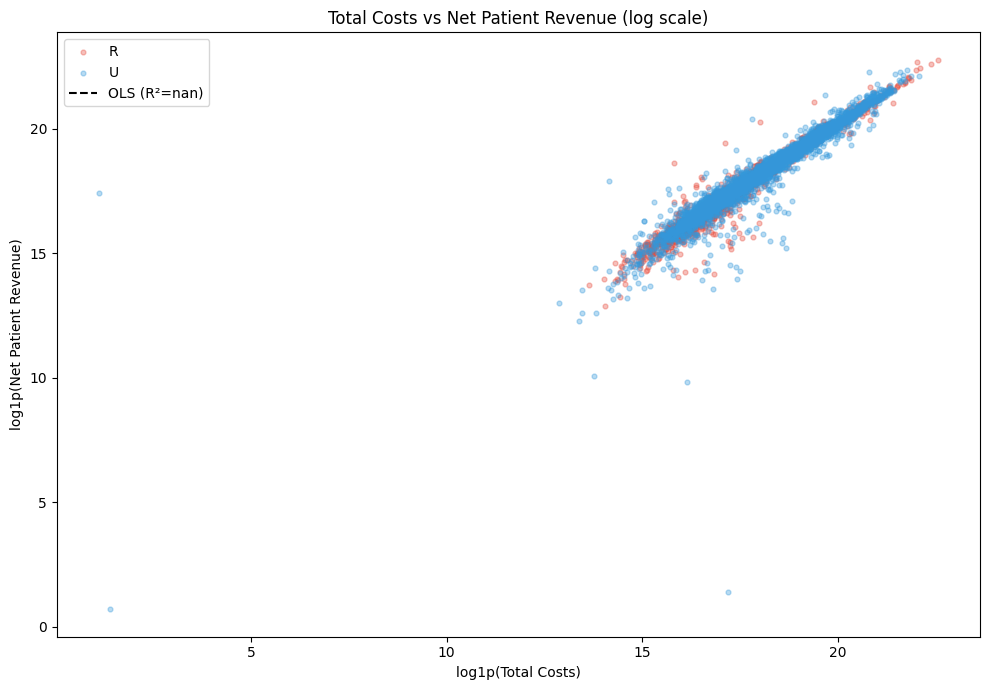

In [34]:
# Scatter: Total Costs vs Net Patient Revenue (coloured by Rural/Urban)
sample = df[['total_costs','net_patient_revenue','rural_urban']].dropna().sample(
    min(8000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
colors = {'R': '#E74C3C', 'U': '#3498DB', 'NA': '#95A5A6'}
for label, grp in sample.groupby('rural_urban'):
    ax.scatter(np.log1p(grp['total_costs']),
               np.log1p(grp['net_patient_revenue']),
               alpha=0.35, s=12, label=label,
               color=colors.get(label, '#95A5A6'))

x = np.log1p(sample['total_costs'])
y = np.log1p(sample['net_patient_revenue'])
idx = x.index.intersection(y.index)
m, b, r, p, _ = stats.linregress(x[idx], y[idx])
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline+b, color='black', linewidth=1.5,
        linestyle='--', label=f'OLS (R²={r**2:.3f})')

ax.set_xlabel('log1p(Total Costs)')
ax.set_ylabel('log1p(Net Patient Revenue)')
ax.set_title('Total Costs vs Net Patient Revenue (log scale)')
ax.legend()
plt.tight_layout()
plt.show()


The scatterplot reveals a strong positive linear relationship between the net patient revenue and total cost variables. As total hospital costs increase, net patient revenue also increases at a very similar rate. This pattern suggests that hospitals with larger operating budgets generally generate higher patient revenue, which is expected because larger hospitals typically treat more patients, operate more service lines, and maintain larger infrastructures. The tight clustering of points along a diagonal line indicates that costs and revenues scale together, meaning that hospitals with higher operating costs tend to have proportionally higher patient revenue.

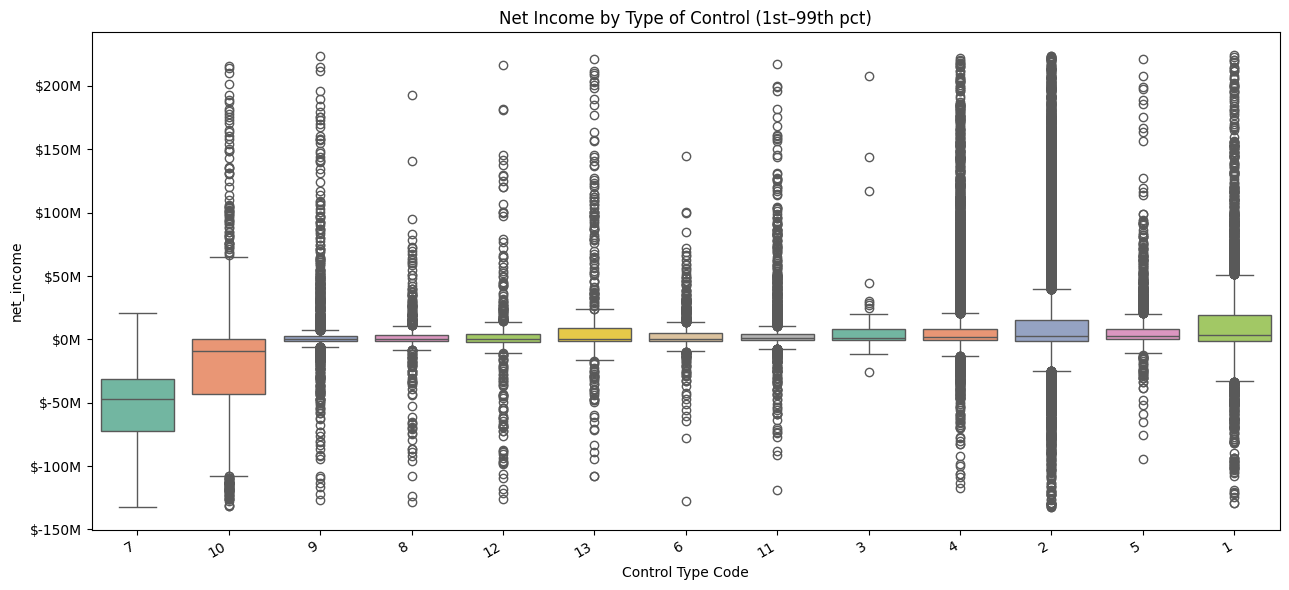

In [36]:
# Net Income by Control Type
if 'control_type' in df.columns and 'net_income' in df.columns:
    plot_data = df[['control_type','net_income']].dropna()
    q1, q3 = plot_data['net_income'].quantile([.01, .99])
    plot_data = plot_data[plot_data['net_income'].between(q1, q3)]
    order = (plot_data.groupby('control_type')['net_income']
                      .median().sort_values().index)

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(data=plot_data, x='control_type', y='net_income',
                order=order, palette='Set2', ax=ax)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    ax.set_title('Net Income by Type of Control (1st–99th pct)')
    ax.set_xlabel('Control Type Code')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


 Saved → ADS599_Capstone/EDA/09_net_income_rural_urban.png


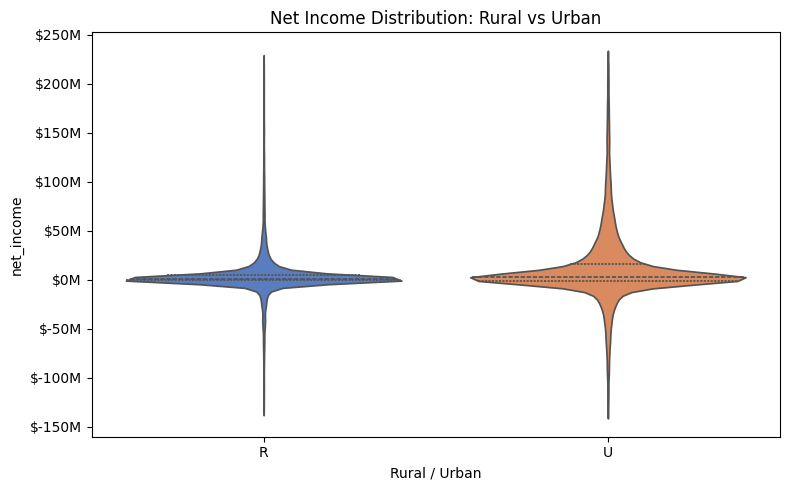

In [37]:
# Net Income: Rural vs Urban violin
if 'rural_urban' in df.columns and 'net_income' in df.columns:
    plot_data = df[['rural_urban','net_income']].dropna()
    q1, q3 = plot_data['net_income'].quantile([.01, .99])
    plot_data = plot_data[plot_data['net_income'].between(q1, q3)]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.violinplot(data=plot_data, x='rural_urban', y='net_income',
                   palette='muted', inner='quartile', ax=ax)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    ax.set_title('Net Income Distribution: Rural vs Urban')
    ax.set_xlabel('Rural / Urban')
    plt.tight_layout()
    save_fig('09_net_income_rural_urban.png')
    plt.show()